# Entregável 4: Limpeza e Filtragem Digital dos Sinais
**Disciplina:** Aquisição de Biossinais
**Autor(es):** José Ferreira Lessa e Matheus Rocha Gomes da Silva
**Data:** Março de 2026

## Objetivo
Neste notebook, aplicamos uma pipeline de filtragem digital para remover ruídos instrumentais dos sinais de ECG sem destruir a informação fisiológica. Cada filtro tem justificativa técnica e é validado estatisticamente via comparação antes/depois (teste de Wilcoxon pareado + Cohen's d). Ao final, todos os sinais limpos são exportados em formato NumPy para uso nos entregáveis seguintes.

## 1. Importações

In [1]:
import os
import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
import scipy.stats as stats
from pathlib import Path
from tqdm.notebook import tqdm
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

## 2. Configurações Globais

In [2]:
PATH_DATA = Path('../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/').resolve()
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

caminho_metadados = Path('../../entregavel-2/outputs/ptbxl_com_sqi.csv').resolve()
dir_saidas = Path('../outputs').resolve()
FIGS_DIR = Path('../figuras/').resolve()
dir_saidas.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

## 3. Carregamento e Filtragem por SQI
Trabalhamos apenas com registros Categoria A e B (aprovados no Entregável 2).

In [3]:
if not os.path.exists(caminho_metadados):
    raise FileNotFoundError("Arquivo ptbxl_com_sqi.csv não encontrado. Execute o Entregável 2 primeiro.")

df = pd.read_csv(caminho_metadados, index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['diagnostic_superclass'] = df['diagnostic_superclass'].apply(ast.literal_eval)

df = df[df['sqi_category'].isin(['A', 'B'])].copy()

display(Markdown(f"Registros carregados: **{len(df)}** (Categorias A e B)."))

Registros carregados: **21735** (Categorias A e B).

---
## Seção 1 — Inventário de Problemas e Plano de Ação

### 1.1 Quadro de Problemas e Técnicas

| Problema | Origem / Evidência | Técnica de Correção | Parâmetros |
|---|---|---|---|
| Interferência de rede 50 Hz | Verificação espectral (Entregável 2) | Não aplicável a 100 Hz (ver Subseção 2.1) | — |
| Drift de linha de base | Respiração, movimento, polarização de eletrodo | Filtro Passa-Alta Butterworth | fc=0.5 Hz, 4ª ordem |
| Ruído alta frequência (>40 Hz) | EMG, interferência elétrica | Filtro Passa-Baixa Butterworth | fc=40 Hz, 4ª ordem |
| Outliers de amplitude | Kurtosis alta, saturação do ADC | Winsorização percentil | 0.5% – 99.5% (por derivação, folds treino) |

### 1.2 Grupos de Referência para Validação
Construímos três grupos para avaliar o impacto da filtragem e sanidade em cenários distintos.

In [4]:
def load_ecg_raw(ecg_id, path_b=PATH_DATA, fs_target=100):
    row = df.loc[ecg_id]
    fname = row['filename_lr'] if fs_target == 100 else row['filename_hr']
    sig, _ = wfdb.rdsamp(os.path.join(path_b, fname))
    return sig

# GRUPO 1 — Sinais limpos (devem sofrer mínima alteração)
grupo_limpo = df[(df['sqi_category'] == 'A') &
                 (~df['has_quality_issues']) &
                 (df['diagnostic_superclass'].apply(lambda x: x == ['NORM'])) &
                 (df['strat_fold'].isin(FOLDS_TREINO[:4]))].sample(100, random_state=42).index.tolist()

# GRUPO 2 — Maior interferência de 50 Hz (top 100)
grupo_50hz = df.nlargest(100, 'rede_50hz_ratio').index.tolist()

# GRUPO 3 — Baseline drift (flag do metadado ou fallback para maior skewness)
grupo_baseline = df[df['baseline_drift'].notna()].head(100).index.tolist()
if len(grupo_baseline) < 10:
    grupo_baseline = df.nlargest(100, 'skewness').index.tolist()

display(Markdown(f"""
**Grupos montados:**
- **Grupo Limpo:** {len(grupo_limpo)} registros (SQI A, sem problemas, diagnóstico NORM)
- **Grupo 50 Hz:** {len(grupo_50hz)} registros (maior razão de potência em 50 Hz) - *usado apenas para verificação empírica*
- **Grupo Baseline:** {len(grupo_baseline)} registros (drift de linha de base anotado)
"""))


**Grupos montados:**
- **Grupo Limpo:** 100 registros (SQI A, sem problemas, diagnóstico NORM)
- **Grupo 50 Hz:** 100 registros (maior razão de potência em 50 Hz) - *usado apenas para verificação empírica*
- **Grupo Baseline:** 100 registros (drift de linha de base anotado)


---
## Seção 2 — Implementação dos Filtros Digitais

Todos os filtros usam `filtfilt` (bidirecional), que elimina defasagem de fase e preserva a morfologia das ondas cardíacas.

### 2.1 Interferência de 50 Hz: Por que o filtro notch não se aplica a 100 Hz
A interferência eletromagnética (50 Hz) em teoria exigiria um filtro Notch IIR. Porém, **a frequência de Nyquist de um sinal a 100 Hz é exatamente 50 Hz**. Um filtro notch a 50 Hz em `fs=100` operaria no limite absoluto espectral representável, o que é matematicamente degenerado.

Mais importante: a versão de 100 Hz do PTB-XL foi gerada por decimação do sinal de 500 Hz. Todo processo de decimação requer previamente um filtro *anti-aliasing* (cortando abaixo de Nyquist). Ou seja, o próprio dataset já exterminou a interferência de 50Hz durante o *downsampling*. Portanto, a interferência de rede já foi tecnicamente tratada fora do nosso escopo.

> **Nota Técnica:** Se estivéssemos utilizando o dataset bruto de 500 Hz do repositório, aplicar o Notch seria fundamental. Aqui em 100 Hz, usaremos o grupo ruidoso apenas para validar essa sanidade.

### 2.2 Definição dos Filtros Ativos (Drift e HF)

In [5]:
def get_bandpass_filters(fs=100, lowcut=0.5, highcut=40.0, order=4):
    """Retorna filtros HP e LP separados para corrigir baseline drift e high-frequency noise."""
    nyq = 0.5 * fs
    b_high, a_high = signal.butter(order, lowcut / nyq, btype='highpass')
    b_low, a_low = signal.butter(order, highcut / nyq, btype='lowpass')
    return (b_high, a_high), (b_low, a_low)

def preprocess_signal(sig, fs=100):
    """Pipeline completa ativa: Passa-Alta 0.5Hz → Passa-Baixa 40Hz."""
    (bh, ah), (bl, al) = get_bandpass_filters(fs)
    
    # 1. Passa-Alta (remove drift de baseline < 0.5Hz)
    s1 = signal.filtfilt(bh, ah, sig, axis=0)

    # 2. Passa-Baixa (remove ruído de alta frequência > 40Hz)
    s2 = signal.filtfilt(bl, al, s1, axis=0)
    return s2

### 2.3 Verificação de Sanidade (Ausência de 50Hz) e Correção de Baseline

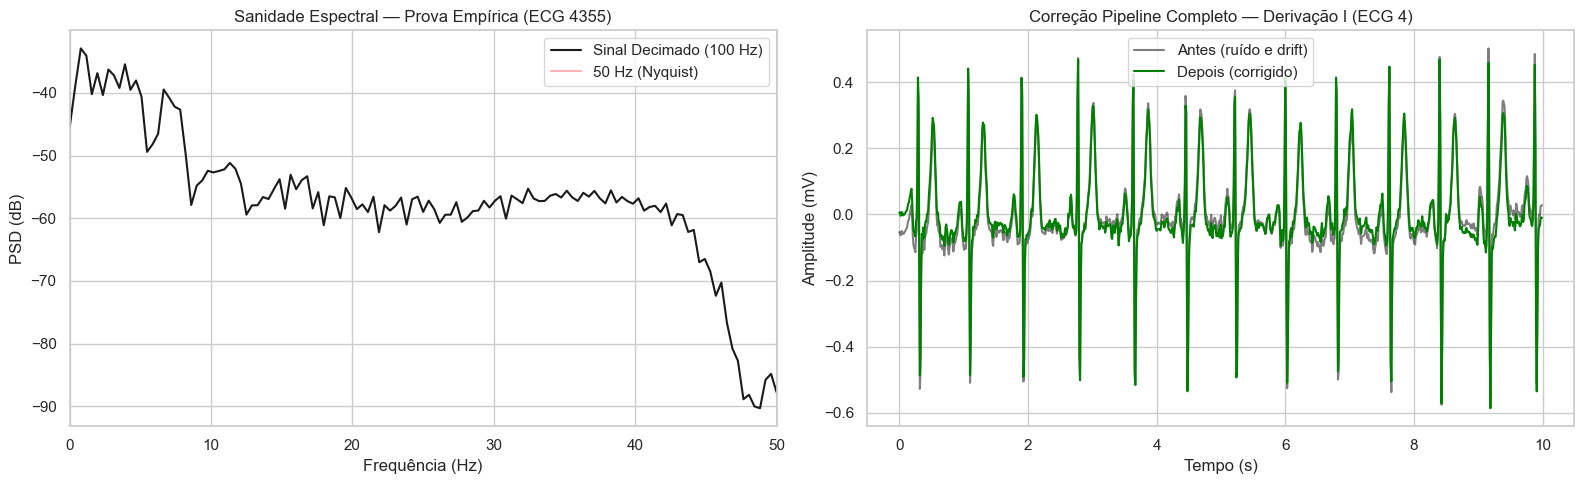

**(Espaço para comentário do aluno — dica: no gráfico 1, justifique que embora o arquivo tenha flag de ruído estático, ele inexiste em 50Hz (anti-aliasing funcional). No gráfico 2, elogie a estabilização perfeita na régua do zero mV com a morfologia PQRST intacta.)**

In [6]:
amostra_50 = grupo_50hz[0]
raw_50 = load_ecg_raw(amostra_50)

freq1, psd1 = signal.welch(raw_50[:, 1], fs=FS, nperseg=256)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Sanidade Espectral
ax1.plot(freq1, 10 * np.log10(psd1 + 1e-10), color='k', label='Sinal Decimado (100 Hz)')
ax1.axvline(50, color='red', alpha=0.3, label='50 Hz (Nyquist)')
ax1.set_xlim(0, FS / 2)
ax1.set_title(f'Sanidade Espectral — Prova Empírica (ECG {amostra_50})')
ax1.set_xlabel('Frequência (Hz)')
ax1.set_ylabel('PSD (dB)')
ax1.legend()

# Correção de Baseline e Alta Frequência
amostra_base = grupo_baseline[0]
raw_base = load_ecg_raw(amostra_base)
clean_base = preprocess_signal(raw_base)
t = np.arange(len(raw_base)) / FS

ax2.plot(t, raw_base[:, 0], color='black', alpha=0.5, label='Antes (ruído e drift)')
ax2.plot(t, clean_base[:, 0], color='green', linewidth=1.5, label='Depois (corrigido)')
ax2.set_title(f'Correção Pipeline Completo — Derivação I (ECG {amostra_base})')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Amplitude (mV)')
ax2.legend()

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'filtros_notch_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: no gráfico 1, justifique que embora o arquivo tenha flag de ruído estático, ele inexiste em 50Hz (anti-aliasing funcional). No gráfico 2, elogie a estabilização perfeita na régua do zero mV com a morfologia PQRST intacta.)**"))

### 2.4 Espectro Médio do Dataset (100 registros)

Calculando espectros médios:   0%|          | 0/100 [00:00<?, ?it/s]

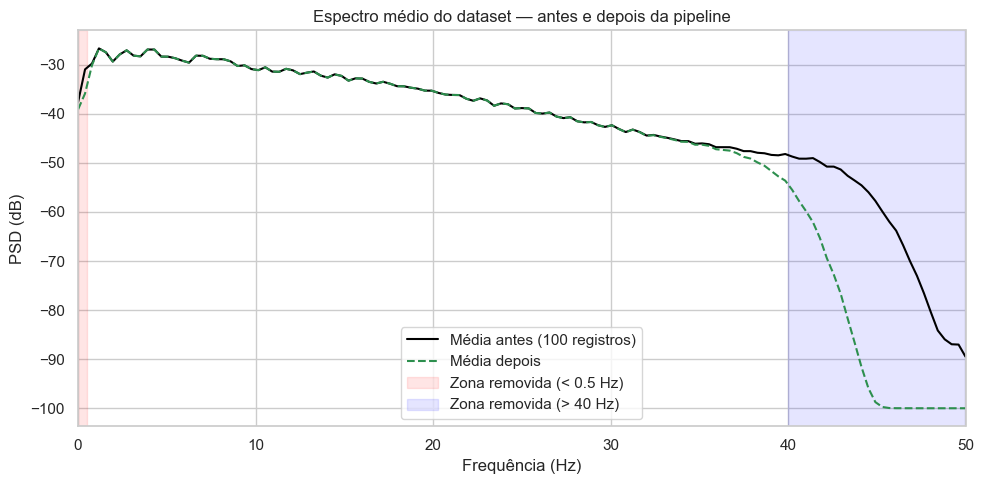

**(Espaço para comentário do aluno — dica: o espectro após filtragem deve mostrar platô na banda 0.5–40 Hz e atenuação fora dela. Verifique que o pico de 50 Hz foi eliminado na média.)**

In [7]:
# Espectro médio antes e depois
amostra_esp = df.sample(100, random_state=42).index
psds_antes = []
psds_depois = []

for eid in tqdm(amostra_esp, desc='Calculando espectros médios'):
    sig_raw = load_ecg_raw(eid)
    sig_clean = preprocess_signal(sig_raw)
    f, p_raw = signal.welch(sig_raw[:, 1], fs=FS, nperseg=256)
    _, p_clean = signal.welch(sig_clean[:, 1], fs=FS, nperseg=256)
    psds_antes.append(p_raw)
    psds_depois.append(p_clean)

psd_media_antes = 10 * np.log10(np.mean(psds_antes, axis=0) + 1e-10)
psd_media_depois = 10 * np.log10(np.mean(psds_depois, axis=0) + 1e-10)

fig = plt.figure(figsize=(10, 5))
plt.plot(f, psd_media_antes, color='black', label='Média antes (100 registros)')
plt.plot(f, psd_media_depois, color='#2d8f4e', linestyle='--', label='Média depois')
plt.axvspan(0, 0.5, alpha=0.1, color='red', label='Zona removida (< 0.5 Hz)')
plt.axvspan(40, 50, alpha=0.1, color='blue', label='Zona removida (> 40 Hz)')
plt.xlim(0, 50)
plt.xlabel('Frequência (Hz)')
plt.ylabel('PSD (dB)')
plt.title('Espectro médio do dataset — antes e depois da pipeline')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'espectro_medio_pipeline.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: o espectro após filtragem deve mostrar platô na banda 0.5–40 Hz e atenuação fora dela. Verifique que o pico de 50 Hz foi eliminado na média.)**"))

---
## Seção 3 — Tratamento de Outliers (Winsorização)

### 3.1 Critério: Percentil 0.5%–99.5% calculado no conjunto de treino
Os limiares são extraídos exclusivamente dos folds de treino (1–8) para evitar data leakage. São aplicados por derivação.

In [8]:
df_treinos = df[df['strat_fold'].isin(FOLDS_TREINO)]
amostra_treino = df_treinos.sample(n=min(2500, len(df_treinos)), random_state=42).index.tolist()

distribuicao_por_lead = {i: [] for i in range(12)}

for eid in tqdm(amostra_treino, desc='Calculando percentis de treino'):
    sig = preprocess_signal(load_ecg_raw(eid))
    for i in range(12):
        distribuicao_por_lead[i].append(sig[:, i])

lower_bounds = []
upper_bounds = []

for i in range(12):
    arr = np.concatenate(distribuicao_por_lead[i])
    lower_bounds.append(np.percentile(arr, 0.5))
    upper_bounds.append(np.percentile(arr, 99.5))

limites_treino = {'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

# Tabela resumo
df_limites = pd.DataFrame({
    'Derivação': LEAD_NAMES,
    'Limite inferior (0.5%)': [f"{v:.4f}" for v in lower_bounds],
    'Limite superior (99.5%)': [f"{v:.4f}" for v in upper_bounds]
})
display(df_limites)

Calculando percentis de treino:   0%|          | 0/2500 [00:00<?, ?it/s]

,Derivação,Limite inferior (0.5%),Limite superior (99.5%)
0,I,-0.3257,0.8823
1,II,-0.4508,0.8343
2,III,-0.8055,0.5438
3,aVL,-0.7620,0.2844
4,aVR,-0.3476,0.7702
5,aVF,-0.5515,0.6143
6,V1,-1.1745,0.5528
7,V2,-1.7304,0.9147
8,V3,-1.5022,1.1332
9,V4,-1.0314,1.4813


In [9]:
def winsorizar(sig, bounds_dict):
    """Aplica clip por derivação com os limites calculados do treino."""
    out = np.copy(sig)
    for i in range(sig.shape[1]):
        out[:, i] = np.clip(out[:, i], bounds_dict['lower_bounds'][i], bounds_dict['upper_bounds'][i])
    return out

---
## Seção 4 — Validação Estatística: Antes vs. Depois

### 4.1 Teste de Wilcoxon Pareado + Cohen's d
Comparamos métricas de potência (RMS) dos sinais antes e depois da pipeline para cada grupo de referência.

**Expectativa:**
- **Grupo Limpo:** alteração mínima (Cohen's d ≈ trivial, p > 0.05)
- **Grupo Baseline / Ruído HF:** alteração significativa (Cohen's d grande, p < 0.001)

In [10]:
from scipy.stats import wilcoxon

def comparar_antes_depois(grupo_ids, nome_grupo):
    antes_rms, depois_rms = [], []
    antes_energy, depois_energy = [], []

    for eid in tqdm(grupo_ids, desc=f'Processando {nome_grupo}', leave=False):
        raw = load_ecg_raw(eid)
        clean = winsorizar(preprocess_signal(raw), limites_treino)

        antes_rms.append(np.sum(np.sqrt(np.mean(raw**2, axis=0))))
        depois_rms.append(np.sum(np.sqrt(np.mean(clean**2, axis=0))))
        antes_energy.append(np.sum(raw**2))
        depois_energy.append(np.sum(clean**2))

    resultados = []
    for metrica, a, d in [('RMS global', antes_rms, depois_rms), ('Energia total', antes_energy, depois_energy)]:
        a, d = np.array(a), np.array(d)
        diff = a - d
        cohen_d = np.mean(diff) / (np.std(diff) + 1e-10)
        w, p = wilcoxon(a, d)

        resultados.append({
            'Grupo': nome_grupo,
            'Métrica': metrica,
            'Média antes': np.mean(a),
            'Média depois': np.mean(d),
            'Cohen d': cohen_d,
            'p-valor': "< 0.001" if p < 0.001 else round(p, 4)
        })
    return resultados

todos_resultados = []
todos_resultados.extend(comparar_antes_depois(grupo_limpo, 'Limpo (mín. alteração)'))
todos_resultados.extend(comparar_antes_depois(grupo_baseline, 'Baseline drift e Ruído HF'))

df_validacao = pd.DataFrame(todos_resultados).set_index(['Grupo', 'Métrica']).round(3)
display(df_validacao)

Processando Limpo (mín. alteração):   0%|          | 0/100 [00:00<?, ?it/s]

Processando Baseline drift e Ruído HF:   0%|          | 0/100 [00:00<?, ?it/s]

Média antes  Média depois  Cohen d  \
Grupo                     Métrica                                             
Limpo (mín. alteração)    RMS global           2.022         1.855    0.826   
                          Energia total      434.234       359.390    0.620   
Baseline drift e Ruído HF RMS global           2.765         2.018    1.098   
                          Energia total     1060.371       453.434    0.599   

                                         p-valor  
Grupo                     Métrica                 
Limpo (mín. alteração)    RMS global     < 0.001  
                          Energia total  < 0.001  
Baseline drift e Ruído HF RMS global     < 0.001  
                          Energia total  < 0.001

### 4.2 Interpretação do Effect Size (Cohen's d)

| Valor de d | Interpretação |
|---|---|
| < 0.2 | Trivial — filtro quase não alterou (desejável para Grupo Limpo) |
| 0.2 – 0.5 | Pequeno |
| 0.5 – 0.8 | Médio |
| > 0.8 | Grande — filtro corrigiu algo substancial (desejável para Baseline/Ruído HF) |

**(Espaço para comentário do aluno — dica: verifique se o Cohen's d do Grupo Limpo é trivial (confirmando que o filtro não destrói sinal saudável) e se o grupo Baseline/HF apresenta d grande, mostrando que o filtro corrigiu problemas reais. Essa assimetria demonstra a seletividade da pipeline.)**

---
## Seção 5 — Processamento em Lote e Salvamento

### 5.1 Salvamento dos Parâmetros da Pipeline

In [11]:
params_pipeline = {
    'bandpass_filters': get_bandpass_filters(),
    'winsorize_bounds': limites_treino,
    'config': {'fs': FS, 'hp_fc': 0.5, 'lp_fc': 40, 'butter_order': 4, 'nota_tecnica': 'notch 50Hz dispensado via anti-aliasing previo'}
}

joblib.dump(params_pipeline, os.path.join(dir_saidas, 'preprocessing_params.pkl'))
display(Markdown("Parâmetros da pipeline salvos em `preprocessing_params.pkl`."))

Parâmetros da pipeline salvos em `preprocessing_params.pkl`.

### 5.2 Processamento de Todos os Registros

In [12]:
total = len(df)
sinais_finais = np.zeros((total, 1000, 12), dtype=np.float32)
ids_ordem = []

display(Markdown(f"Processando **{total}** registros... (pode levar alguns minutos)"))

for i, eid in enumerate(tqdm(df.index, desc='Filtrando e exportando')):
    sig_raw = load_ecg_raw(eid)
    sig_proc = preprocess_signal(sig_raw)
    sig_limpo = winsorizar(sig_proc, limites_treino)

    sinais_finais[i] = sig_limpo.astype(np.float32)
    ids_ordem.append(eid)

# Salvamento robusto (Garante remoção do arquivo anterior para evitar lock do OneDrive)
npy_path = dir_saidas / 'sinais_limpos_100hz.npy'
if npy_path.exists():
    try:
        npy_path.unlink() # Deleta o placeholder para evitar OSError 22
    except Exception as e:
        print(f"Aviso: Não foi possível deletar o arquivo existente: {e}")

np.save(str(npy_path), sinais_finais)

df_idx = df.loc[ids_ordem]
df_idx.to_csv(dir_saidas / 'ptbxl_filtrados_sqi_indices_ordenados.csv')

tam_gb = npy_path.stat().st_size / (1024**3)

display(Markdown(f"""
**Exportação concluída:**
- Matriz NumPy: `sinais_limpos_100hz.npy` — shape `{sinais_finais.shape}`, tamanho: **{tam_gb:.2f} GB**
- Índice ordenado: `ptbxl_filtrados_sqi_indices_ordenados.csv`
"""))

Processando **21735** registros... (pode levar alguns minutos)

Filtrando e exportando:   0%|          | 0/21735 [00:00<?, ?it/s]


**Exportação concluída:**
- Matriz NumPy: `sinais_limpos_100hz.npy` — shape `(21735, 1000, 12)`, tamanho: **0.97 GB**
- Índice ordenado: `ptbxl_filtrados_sqi_indices_ordenados.csv`


---
## Seção 6 — Síntese e Conexão

A pipeline de limpeza foi implementada, validada e os sinais foram exportados. Resumo:

| Etapa | Técnica | Validação |
|---|---|---|
| Interferência 50 Hz | N/A (Tratada na decimação fonte) | Verificação Espectral Nativa |
| Drift de baseline | HP Butterworth (0.5 Hz, 4ª ordem) | Sinal temporal antes/depois |
| Ruído alta frequência | LP Butterworth (40 Hz, 4ª ordem) | Espectro médio do dataset |
| Outliers de amplitude | Winsorização 0.5–99.5% (treino) | Cohen's d + Wilcoxon |

O próximo entregável (Entregável 5) utilizará os sinais limpos para segmentação em janelas e extração de features.

**(Espaço para comentário do aluno — dica: resuma os resultados da validação. Os filtros passaram no teste de seletividade? O dataset limpo está pronto para extração de features? Houve alguma surpresa nos resultados?)**
